In [7]:
# InsightED — Exploratory Data Analysis & Experimental Modeling Pipeline

This notebook serves as the primary experimental scratchpad for **InsightED**. It implements and documents the complete experimental research data lifecycle:
1. Loading the raw dataset.
2. Feature Engineering: Mathematical calculation of `Grade_Momentum`.
3. Target Isolation ($y$ via the $G3 < 10$ cutoff) and Feature filtering ($X$).
4. Data Transformation (Numerical Scaling and Categorical One-Hot Encoding).
5. Minority Class Balancing using SMOTE.
6. Baseline Model Performance Evaluation.

SyntaxError: invalid syntax (1444132597.py, line 3)

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("📥 Loading raw dataset fractions...")
# Note: We use ".." to step up from the 'notebooks' folder to the root before entering 'dataset'
raw_data_path = os.path.join("..", "dataset", "student-por.csv")
df = pd.read_csv(raw_data_path, sep=";")
print(f"✅ Raw Dataset Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} original features.")

# 1. Calculate Grade Momentum before dropping anything
df['Grade_Momentum'] = df['G2'] - df['G1']
print(f"💡 Feature Engineered: 'Grade_Momentum' calculated (G2 - G1). Dimensions expanded to {df.shape[1]} columns.")

# Preview the engineered trend matrices
df[['G1', 'G2', 'Grade_Momentum']].head()

📥 Loading raw dataset fractions...
✅ Raw Dataset Loaded Successfully: 649 rows, 33 original features.
💡 Feature Engineered: 'Grade_Momentum' calculated (G2 - G1). Dimensions expanded to 34 columns.


,G1,G2,Grade_Momentum
0,0,11,11
1,9,11,2
2,12,13,1
3,14,14,0
4,11,13,2


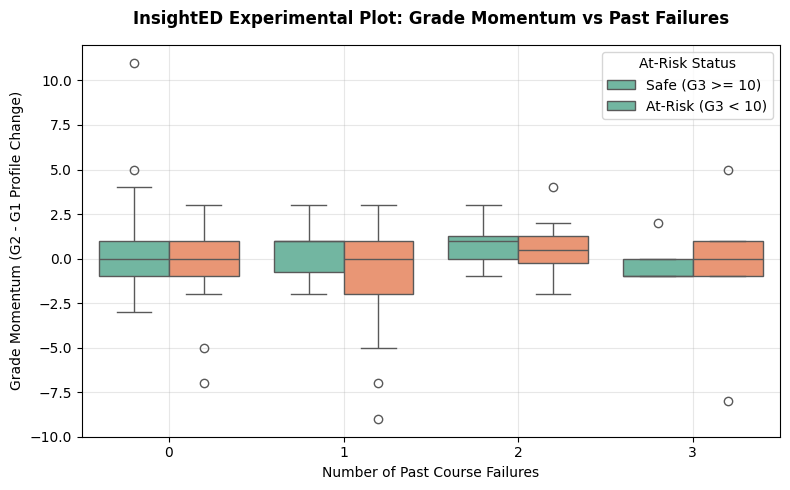

In [ ]:
# Create a beautiful boxplot checking how Academic Failures interact with Grade Momentum for your results chapter
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='failures', y='Grade_Momentum', hue=(df['G3'] < 10), palette='Set2')
plt.title('InsightED Experimental Plot: Grade Momentum vs Past Failures', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Number of Past Course Failures')
plt.ylabel('Grade Momentum (G2 - G1 Profile Change)')
plt.legend(title='At-Risk Status', labels=['Safe (G3 >= 10)', 'At-Risk (G3 < 10)'])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE

print("⚙️ Initiating target isolation and filtering...")
# Isolate target label 'y' based on the approved proposal threshold (< 10)
y = (df['G3'] < 10).astype(int)

# Filter out noise columns and drop G3 from input features
noise_cols = ['school', 'reason', 'guardian', 'famsup', 'paid', 'higher', 'nursery', 'romantic',  'G3']
X = df.drop(columns=noise_cols)

# Stratified split to preserve class distribution proportions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Separate variable arrays for customized matrix transformation
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Fit and apply standard scaling and one-hot encoding
scaler = StandardScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_num = scaler.fit_transform(X_train[num_cols])
X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_train_proc = np.hstack((X_train_num, X_train_cat))

print(f"📐 Processed array dimensions: {X_train_proc.shape[1]} inputs scaled and encoded.")

# Address data imbalance via SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_proc, y_train)
print(f"⚖️ SMOTE Balancer Complete: Safe class count: {np.bincount(y_res)[0]} | At-Risk class count: {np.bincount(y_res)[1]}")

⚙️ Initiating target isolation and filtering...
📐 Processed array dimensions: 42 inputs scaled and encoded.


C:\Users\D  A  COMPUTERS\AppData\Local\Temp\ipykernel_10604\1431432893.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


⚖️ SMOTE Balancer Complete: Safe class count: 439 | At-Risk class count: 439


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

print("🏋️‍♂️ Training baseline experimental Logistic Regression classifier...")
lr_experimental = LogisticRegression(max_iter=1000, random_state=42)
lr_experimental.fit(X_res, y_res)

# Transform the independent test set vectors
X_test_num = scaler.transform(X_test[num_cols])
X_test_cat = encoder.transform(X_test[cat_cols])
X_test_proc = np.hstack((X_test_num, X_test_cat))

# Evaluate model outputs
y_pred = lr_experimental.predict(X_test_proc)
print("\n📊 --- EXPERIMENTAL TESTING METRIC PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'At-Risk (1)']))
print("----------------------------------------------------------")

🏋️‍♂️ Training baseline experimental Logistic Regression classifier...

📊 --- EXPERIMENTAL TESTING METRIC PERFORMANCE REPORT ---
              precision    recall  f1-score   support

    Safe (0)       0.98      0.91      0.94       110
 At-Risk (1)       0.64      0.90      0.75        20

    accuracy                           0.91       130
   macro avg       0.81      0.90      0.85       130
weighted avg       0.93      0.91      0.91       130

----------------------------------------------------------


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("🏋️‍♂️ Training advanced Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_res, y_res)

# Evaluate advanced model
y_pred_rf = rf_model.predict(X_test_proc)
print("\n📊 --- RANDOM FOREST TESTING PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred_rf, target_names=['Safe (0)', 'At-Risk (1)']))

🏋️‍♂️ Training advanced Random Forest Classifier...

📊 --- RANDOM FOREST TESTING PERFORMANCE REPORT ---
              precision    recall  f1-score   support

    Safe (0)       0.97      0.92      0.94       110
 At-Risk (1)       0.65      0.85      0.74        20

    accuracy                           0.91       130
   macro avg       0.81      0.88      0.84       130
weighted avg       0.92      0.91      0.91       130



In [ ]:
from xgboost import XGBClassifier

print("🏋️‍♂️ Training advanced XGBoost Classifier...")
# We use scale_pos_weight to help XGBoost handle any remaining class imbalances cleanly
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
xgb_model.fit(X_res, y_res)

# Evaluate XGBoost
y_pred_xgb = xgb_model.predict(X_test_proc)
print("\n📊 --- XGBOOST TESTING PERFORMANCE REPORT ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Safe (0)', 'At-Risk (1)']))

🏋️‍♂️ Training advanced XGBoost Classifier...

📊 --- XGBOOST TESTING PERFORMANCE REPORT ---
              precision    recall  f1-score   support

    Safe (0)       0.96      0.95      0.96       110
 At-Risk (1)       0.76      0.80      0.78        20

    accuracy                           0.93       130
   macro avg       0.86      0.88      0.87       130
weighted avg       0.93      0.93      0.93       130



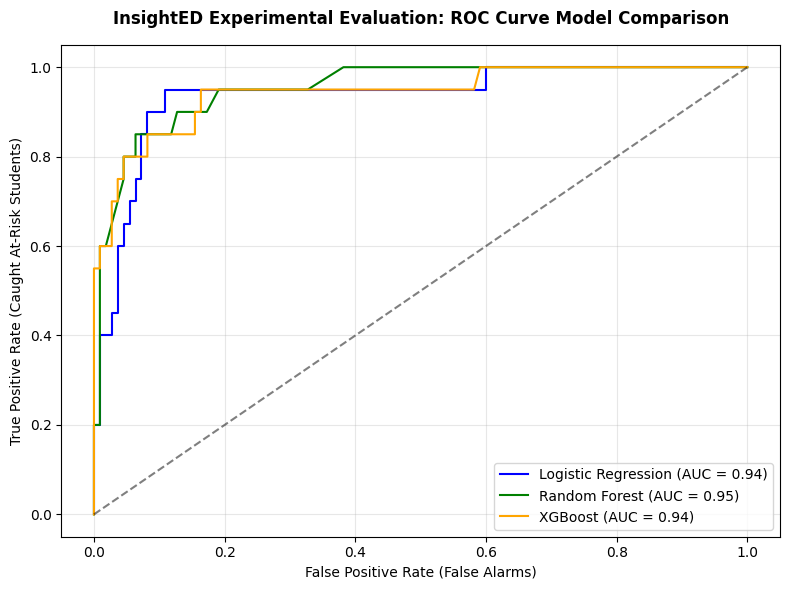

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

# Plot Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_experimental.predict_proba(X_test_proc)[:, 1])
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc(fpr_lr, tpr_lr):.2f})', color='blue')

# Plot Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test_proc)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.2f})', color='green')

# Plot XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_model.predict_proba(X_test_proc)[:, 1])
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.2f})', color='orange')

# Chart formatting
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.title('InsightED Experimental Evaluation: ROC Curve Model Comparison', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Caught At-Risk Students)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

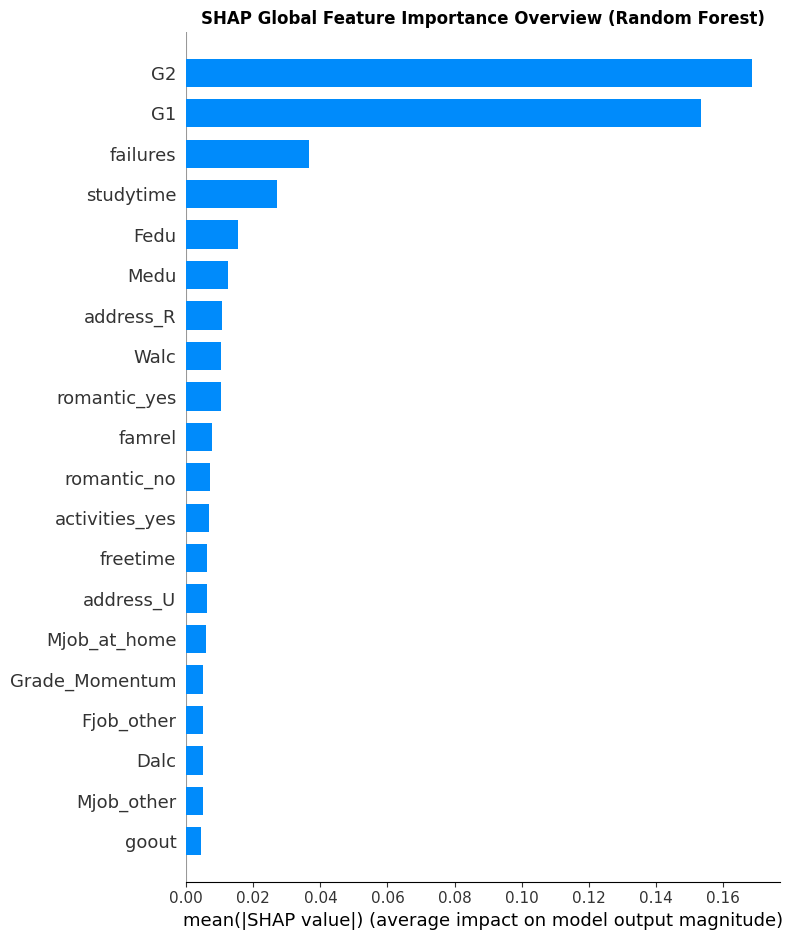

In [ ]:
import shap

# Compute SHAP values using a Tree Explainer for your advanced models
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_proc)

# Extract feature names cleanly
feature_names = num_cols + list(encoder.get_feature_names_out(cat_cols))

# Generate the global summary plot
plt.title("SHAP Global Feature Importance Overview (Random Forest)", fontsize=12, fontweight='bold')
shap.summary_plot(shap_values_rf[:, :, 1], X_test_proc, feature_names=feature_names, plot_type="bar")

In [ ]:
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

# 1. Set up the LIME explainer tool
explainer_lime = LimeTabularExplainer(
    training_data=X_res,
    feature_names=feature_names,
    class_names=['Safe', 'At-Risk'],
    mode='classification'
)

# 2. Pick an individual student from your test set (e.g., index 5)
student_index = 5
exp = explainer_lime.explain_instance(
    data_row=X_test_proc[student_index],
    predict_fn=rf_model.predict_proba
)

# 3. FIX: Generate HTML raw string and display it safely in VS Code
html_data = exp.as_html(show_table=True)
display(HTML(html_data))

📊 Generating SHAP global feature importance values...


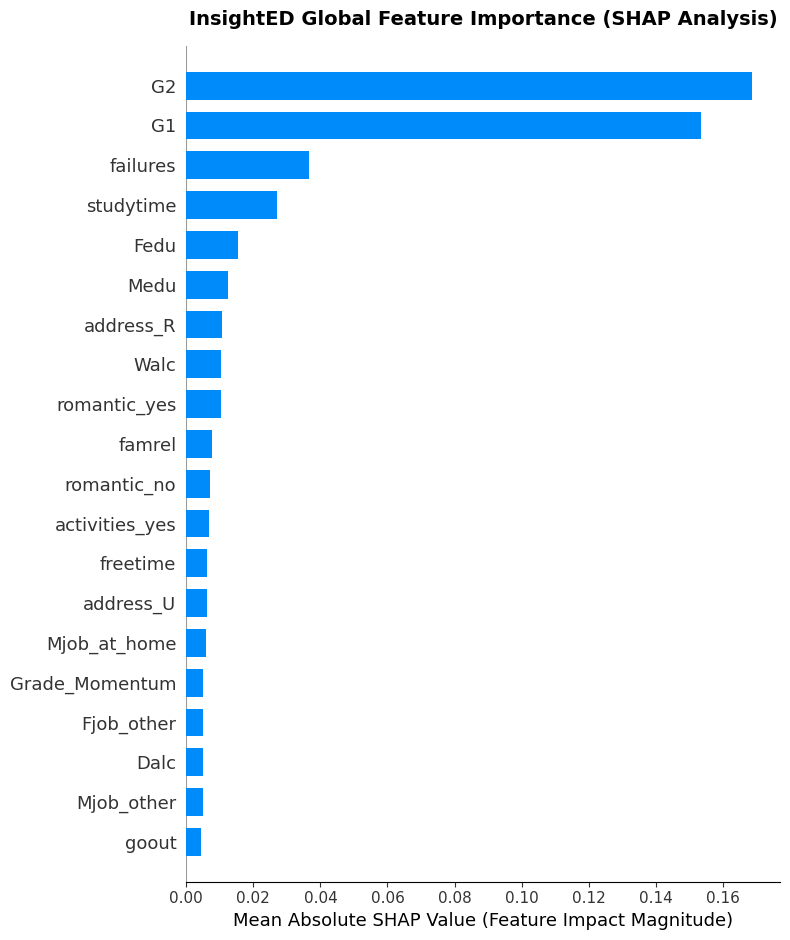

In [ ]:
import shap
import matplotlib.pyplot as plt

print("📊 Generating SHAP global feature importance values...")
# Initialize the Tree Explainer using your trained Random Forest model
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test_proc)

# Extract feature names cleanly from your preprocessor pipeline
feature_names = num_cols + list(encoder.get_feature_names_out(cat_cols))

# Create the plot window
plt.figure(figsize=(10, 6))
plt.title("InsightED Global Feature Importance (SHAP Analysis)", fontsize=14, fontweight='bold', pad=15)

# Generate the bar chart for the 'At-Risk' class (index 1)
shap.summary_plot(shap_values_rf[:, :, 1], X_test_proc, feature_names=feature_names, plot_type="bar", show=False)

plt.xlabel("Mean Absolute SHAP Value (Feature Impact Magnitude)")
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import os

# This creates 'notebooks/experimental_models/' relative to where this notebook sits
export_dir = os.path.join("experimental_models")
os.makedirs(export_dir, exist_ok=True)

print("💾 Saving notebook experimental artifacts...")
joblib.dump(xgb_model, os.path.join(export_dir, "exp_xgb_classifier.pkl"))
joblib.dump(scaler, os.path.join(export_dir, "exp_numerical_scaler.pkl"))
joblib.dump(encoder, os.path.join(export_dir, "exp_categorical_encoder.pkl"))

print(f"✅ Notebook artifacts saved cleanly in: {os.path.abspath(export_dir)}")

💾 Saving notebook experimental artifacts...
✅ Notebook artifacts saved cleanly in: c:\Users\D  A  COMPUTERS\Desktop\InsightED\notebooks\experimental_models


In [ ]:
print("==================================================")
print("📊 VERIFYING THESIS DATASET NUMBERS")
print("==================================================")

# 1. Raw Dataset Balance (Before SMOTE)
# Replace 'y' with your actual target variable name if it's different
raw_counts = y.value_counts()
print("▶️ RAW DATASET DISTRIBUTION (Before SMOTE):")
for label, count in raw_counts.items():
    status = "Safe (0)" if label == 0 else "At-Risk (1)"
    print(f"   - {status}: {count} students")

print(f"   - Total Raw Records: {len(y)} students")
print("-" * 50)

# 2. Balanced Training Set (After SMOTE)
# Replace 'y_train_resampled' with your post-SMOTE target variable name
try:
    smote_counts = pd.Series(y_train_resampled).value_counts()
    print("▶️ RESAMPLED TRAINING DISTRIBUTION (After SMOTE):")
    for label, count in smote_counts.items():
        status = "Safe (0)" if label == 0 else "At-Risk (1)"
        print(f"   - {status}: {count} samples")
    print(f"   - Total Resampled Training Size: {len(y_train_resampled)}")
except NameError:
    print("⚠️ Could not find y_train_resampled. Check your SMOTE variable name!")
print("==================================================")

📊 VERIFYING THESIS DATASET NUMBERS


NameError: name 'y' is not defined